# 02 -- Chromosome velocity depends on position, not time

Before fitting any spatial force model, we establish that chromosome
velocities are determined by *where* a chromosome is, not *when* it
got there.  Two comparisons (cf. old paper Fig 2A–B):

**A)** Chromosomes starting far vs close from the spindle center show
indistinguishable velocity distributions in the same spatial region
(3–5 µm) → no time/history dependence.

**B)** The same far-starting chromosomes have significantly different
velocities at different distances → velocity is distance-dependent.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from chromlearn import find_repo_root

ROOT = find_repo_root(Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd())

from chromlearn.analysis.velocity_vs_distance import (
    compute_binned_velocities,
    plot_binned_velocities,
)
from chromlearn.io.catalog import load_condition
from chromlearn.io.trajectory import trim_trajectory

plt.rcParams["figure.dpi"] = 110

In [2]:
cells_raw = load_condition("rpe18_ctr")
cells = [trim_trajectory(c, method="neb_ao_frac", frac=1.0) for c in cells_raw]
print(f"Loaded {len(cells)} rpe18_ctr cells")

Loaded 12 rpe18_ctr cells


## Main result: spatial vs temporal velocity

Using the same thresholds as the original analysis:
far/close split at 5 µm, comparison region 3–5 µm, far region 5–15 µm.

In [3]:
result = compute_binned_velocities(cells)

def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * np.var(a, ddof=1) + (nb - 1) * np.var(b, ddof=1)) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / pooled_std if pooled_std > 0 else 0.0

d_a = cohens_d(result.startfar_region1, result.startclose_region1)
d_b = cohens_d(result.startfar_region1_b, result.startfar_region2)

print(f"Panel A — same region ({result.region1_bounds}), different starting distance:")
print(f"  Started far:   n = {len(result.startfar_region1)}, mean = {result.startfar_region1.mean():.3f}")
print(f"  Started close: n = {len(result.startclose_region1)}, mean = {result.startclose_region1.mean():.3f}")
print(f"  Cohen's d = {d_a:.4f}  (negligible if |d| < 0.2)")
print(f"  t-test: T = {result.ttest_a.statistic:.4f}, p = {result.ttest_a.pvalue:.4g}")
print(f"  KS test: D = {result.ks_a.statistic:.4f}, p = {result.ks_a.pvalue:.4g}")
print()
print(f"Panel B — started far, different regions:")
print(f"  Region {result.region1_bounds}: n = {len(result.startfar_region1_b)}, mean = {result.startfar_region1_b.mean():.3f}")
print(f"  Region {result.region2_bounds}: n = {len(result.startfar_region2)}, mean = {result.startfar_region2.mean():.3f}")
print(f"  Cohen's d = {d_b:.4f}  (large if |d| > 0.8)")
print(f"  t-test: T = {result.ttest_b.statistic:.4f}, p = {result.ttest_b.pvalue:.4g}")
print(f"  KS test: D = {result.ks_b.statistic:.4f}, p = {result.ks_b.pvalue:.4g}")

Panel A — same region ((3.0, 5.0)), different starting distance:
  Started far:   n = 50672, mean = 2.385
  Started close: n = 36000, mean = 2.410
  Cohen's d = -0.0183  (negligible if |d| < 0.2)
  t-test: T = -2.6417, p = 0.008251
  KS test: D = 0.0097, p = 0.03848

Panel B — started far, different regions:
  Region (3.0, 5.0): n = 50672, mean = 2.385
  Region (5.0, 15.0): n = 12949, mean = 2.893
  Cohen's d = -0.3466  (large if |d| > 0.8)
  t-test: T = -28.1369, p = 4.394e-170
  KS test: D = 0.1041, p = 8.6e-98


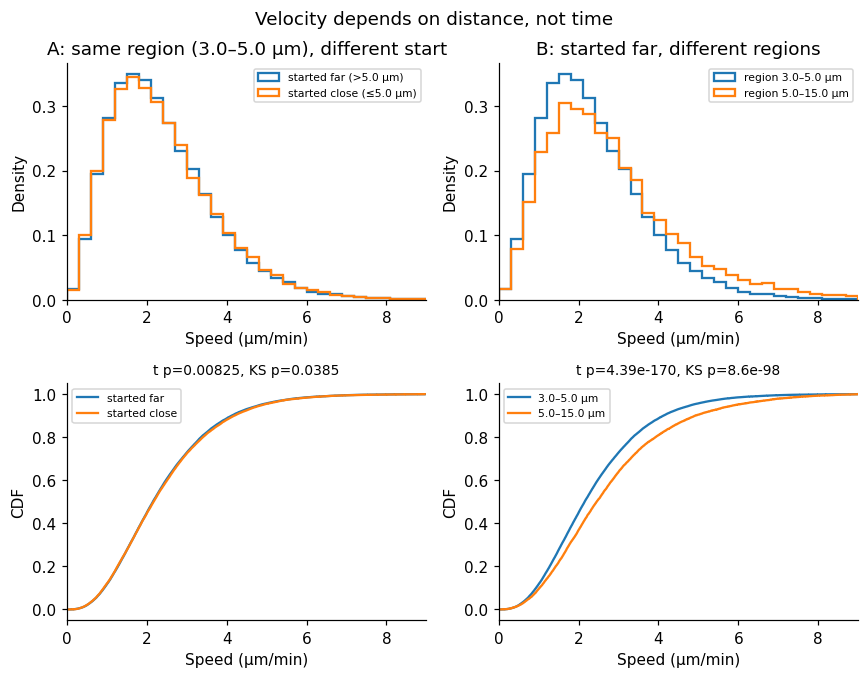

In [4]:
fig = plot_binned_velocities(result)
fig.suptitle("Velocity depends on distance, not time", fontsize=12, y=1.02)
plt.show()

## Sensitivity to threshold choice

Vary the far/close split threshold.  Effect sizes (Cohen's d) are the
meaningful metric here — p-values are uninformative at n ≈ 50–90K frames.
Panel A d should stay negligible; Panel B d should stay meaningful.

In [5]:
thresholds = [3.0, 4.0, 5.0, 6.0, 7.0]
print(f"{'threshold':>10} {'n_far_r1':>10} {'n_close_r1':>12} "
      f"{'d_A':>8} {'d_B':>8} {'KS_A':>8} {'KS_B':>8}")

for thr in thresholds:
    r = compute_binned_velocities(cells, far_threshold=thr)
    d_a_ = cohens_d(r.startfar_region1, r.startclose_region1)
    d_b_ = cohens_d(r.startfar_region1_b, r.startfar_region2)
    print(f"{thr:>10.1f} {len(r.startfar_region1):>10} {len(r.startclose_region1):>12} "
          f"{d_a_:>8.3f} {d_b_:>8.3f} "
          f"{r.ks_a.statistic:>8.4f} {r.ks_b.statistic:>8.4f}")

 threshold   n_far_r1   n_close_r1      d_A      d_B     KS_A     KS_B
       3.0      81575         5097    0.036   -0.339   0.0273   0.1025
       4.0      69646        17026    0.038   -0.341   0.0241   0.1031
       5.0      50672        36000   -0.018   -0.347   0.0097   0.1041


       6.0      30972        55700   -0.032   -0.375   0.0169   0.1176
       7.0      16194        70478   -0.016   -0.359   0.0116   0.1140


## Velocity vs distance profile

Complement to the binned test: mean and median velocity magnitude as a
continuous function of distance to spindle center.

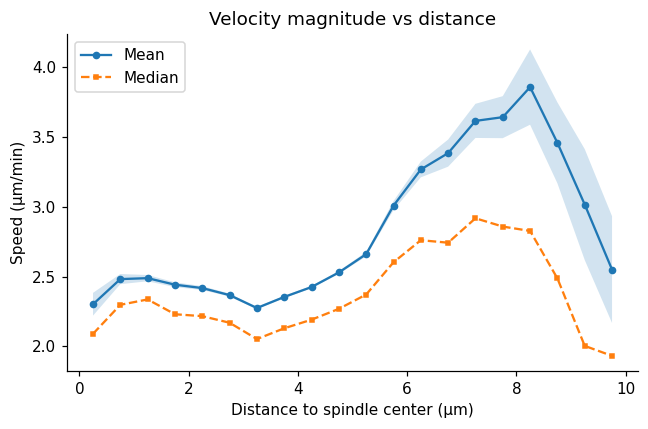

In [6]:
from chromlearn.io.trajectory import pole_center

all_dist = []
all_vel = []
for cell in cells:
    center = pole_center(cell)
    dt_min = cell.dt / 60.0
    for k in range(cell.tracked):
        pos = cell.chromosomes[:, :, k]
        if np.any(np.isnan(pos)):
            continue
        dist = np.linalg.norm(pos - center, axis=1)
        vel = np.linalg.norm(np.diff(pos, axis=0), axis=1) / dt_min
        all_dist.append(dist[:-1])
        all_vel.append(vel)

all_dist = np.concatenate(all_dist)
all_vel = np.concatenate(all_vel)

# Bin by distance
bin_edges = np.arange(0, 16, 0.5)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
means = np.full(len(bin_centers), np.nan)
medians = np.full(len(bin_centers), np.nan)
sems = np.full(len(bin_centers), np.nan)

for i in range(len(bin_centers)):
    mask = (all_dist >= bin_edges[i]) & (all_dist < bin_edges[i + 1])
    if mask.sum() > 5:
        means[i] = np.mean(all_vel[mask])
        medians[i] = np.median(all_vel[mask])
        sems[i] = np.std(all_vel[mask]) / np.sqrt(mask.sum())

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bin_centers, means, "o-", markersize=4, label="Mean")
ax.fill_between(bin_centers, means - sems, means + sems, alpha=0.2)
ax.plot(bin_centers, medians, "s--", markersize=3, label="Median")
ax.set_xlabel("Distance to spindle center (µm)")
ax.set_ylabel("Speed (µm/min)")
ax.set_title("Velocity magnitude vs distance")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Chromosome-level permutation test on Panel A

The frame-level t-test rejects despite negligible effect size (d ≈ 0.03)
because n ≈ 95K frames have massive power. But frames within a trajectory
are autocorrelated, so the effective sample size is much smaller.

The correct unit of replication is the *chromosome*: each contributes its
mean velocity in the 3–5 µm region as one data point.  We shuffle the
"started far/close" labels across chromosomes and recompute Δmean.

In [7]:
from chromlearn.analysis.velocity_vs_distance import permutation_test_panel_a

perm_result = permutation_test_panel_a(cells, n_permutations=10000, rng_seed=42)
print(f"Chromosomes: {perm_result.n_far_chroms} far, {perm_result.n_close_chroms} close")
print(f"Observed Δmean = {perm_result.observed_diff:.4f} µm/min")
print(f"Permutation p = {perm_result.p_value:.4g}  (n = {perm_result.n_permutations})")
print(f"95% CI of null Δmean: [{perm_result.null_ci[0]:.4f}, {perm_result.null_ci[1]:.4f}]")

Chromosomes: 296 far, 239 close
Observed Δmean = -0.0000 µm/min
Permutation p = 0.9995  (n = 10000)
95% CI of null Δmean: [-0.0757, 0.0741]


---
**Dev note:** We also tried a within-distance-bin partial correlation test
(Spearman ρ of velocity vs normalized time, combined with Fisher's method).
It rejected the null, but the test has a confound: chromosomes at the same
distance but different "times" have systematically different trajectory
histories (converging vs hovering), which creates spurious velocity–time
correlation that isn't about time-dependent forces.  Dropped in favor of
the cleaner binned comparison + chromosome-level permutation above.